# Actividad 6: $\epsilon$-greedy method on the 10-armed bandit problem
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Autónoma de Yucatán
### 20 de Mayo 2026


### 1. Introduction
In this activity, we implement the $\epsilon$-greedy algorithm to solve a 10-armed bandit problem. The goal is to evaluate its performance with different values of $\epsilon$ ($0.1, 0.01, 0.009$) and observe the trade-off between exploration and exploitation.

The 10-armed bandit problem consists of:
- **10 actions**: Each action has a reward distribution with a mean $q_*(a)$ and unit variance.
- **$q_*(a)$**: Sampled from a normal distribution $\mathcal{N}(0, 1)$.
- **Incremental Update**: Estimates are updated using $Q_{t+1}(a) = Q_t(a) + \frac{1}{n}[R_t - Q_t(a)]$.


### 2. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt


### 3. Environment and Algorithm Implementation
#### 3.1 Bandit Environment
The `Bandit` class simulates the 10-armed bandit. Each arm's true value $q_*$ is chosen from $\mathcal{N}(0, 1)$, and actual rewards are $R \sim \mathcal{N}(q_*, 1)$.

In [4]:
class Bandit:
    def __init__(self, k_arm=10):
        self.k = k_arm
        self.q_star = np.random.normal(0, 1, self.k)
        self.optimal_action = np.argmax(self.q_star)

    def step(self, action):
        reward = np.random.normal(self.q_star[action], 1)
        return reward


#### 3.2 Experiment Runner
The `run_experiment` function simulates the agent's interaction with the environment over multiple runs and steps.

In [5]:
def run_experiment(epsilon, steps=1000, runs=2000, k_arm=10):
    all_rewards = np.zeros((runs, steps))
    optimal_action_counts = np.zeros((runs, steps))

    for r in range(runs):
        bandit = Bandit(k_arm)
        q_estimates = np.zeros(k_arm)
        action_counts = np.zeros(k_arm)
        
        for s in range(steps):
            # Epsilon-greedy selection
            if np.random.rand() < epsilon:
                action = np.random.choice(k_arm)
            else:
                # Tie-breaking: choose randomly among max values
                max_q = np.max(q_estimates)
                action = np.random.choice(np.where(q_estimates == max_q)[0])

            reward = bandit.step(action)
            action_counts[action] += 1
            # Incremental update: Q(a) = Q(a) + 1/n * [R - Q(a)]
            q_estimates[action] += (reward - q_estimates[action]) / action_counts[action]

            all_rewards[r, s] = reward
            if action == bandit.optimal_action:
                optimal_action_counts[r, s] = 1

    avg_rewards = np.mean(all_rewards, axis=0)
    avg_optimal_action = np.mean(optimal_action_counts, axis=0)
    return avg_rewards, avg_optimal_action


### 4. Simulation Execution
We run the simulation for $\epsilon \in \{0.1, 0.01, 0.009\}$.

In [6]:
# Parameters
epsilons = [0.1, 0.01, 0.009]
steps = 1000
runs = 2000

results = {}
for eps in epsilons:
    print(f"Running simulation for epsilon = {eps}...")
    results[eps] = run_experiment(eps, steps, runs)


Running simulation for epsilon = 0.1...
Running simulation for epsilon = 0.01...
Running simulation for epsilon = 0.009...


### 5. Results Visualization
We compare the average reward and the percentage of optimal action selection over time.

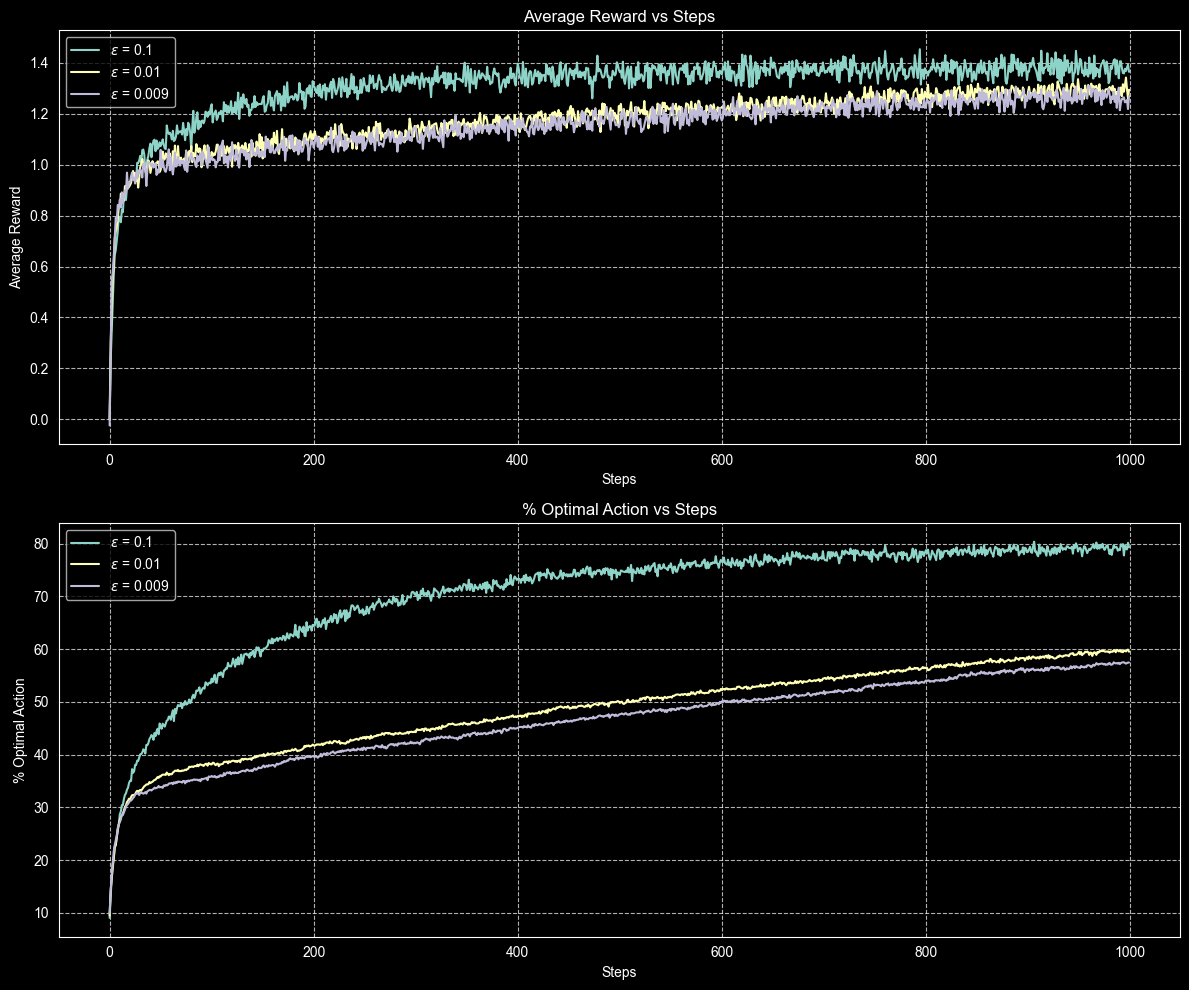

In [7]:
# Plotting Results
plt.figure(figsize=(12, 10))

# Plot Average Reward
plt.subplot(2, 1, 1)
for eps in epsilons:
    plt.plot(results[eps][0], label=rf'$\epsilon$ = {eps}')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Average Reward vs Steps')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot % Optimal Action
plt.subplot(2, 1, 2)
for eps in epsilons:
    plt.plot(results[eps][1] * 100, label=rf'$\epsilon$ = {eps}')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.title('% Optimal Action vs Steps')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()


### 6. Analysis
From the plots, we can observe:
- **$\epsilon = 0.1$**: Explores more frequently, leading to faster discovery of the optimal action but a lower long-term average reward due to continued exploration (10% of the time).
- **$\epsilon = 0.01$ and $\epsilon = 0.009$**: Explore less, which means they take longer to find the optimal action, but their performance eventually surpasses $\epsilon = 0.1$ as they exploit the optimal action more often.
- The **$\epsilon$-greedy method** illustrates the fundamental exploration-exploitation trade-off in reinforcement learning.
